In [12]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import joblib

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

PyTorch version: 2.5.1+cu121
CUDA available: True
Using device: cuda


In [2]:
X_train = np.load('../data/processed/X_train.npy')
X_test = np.load('../data/processed/X_test.npy')

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")


X_train: (37331, 30, 9)
X_test:  (9333, 30, 9)


In [3]:
# Convert to tensors
X_train_tensor = torch.FloatTensor(X_train).to(device)
X_test_tensor = torch.FloatTensor(X_test).to(device)

# Create datasets and loaders
train_dataset = TensorDataset(X_train_tensor, X_train_tensor)  # input = target (autoencoder)
test_dataset = TensorDataset(X_test_tensor, X_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches:  {len(test_loader)}")

Train batches: 584
Test batches:  146


In [4]:
class LSTMAutoencoder(nn.Module):
    def __init__(self, n_features, hidden_size=64, n_layers=2, dropout=0.2):
        super(LSTMAutoencoder, self).__init__()
        
        # Encoder
        self.encoder = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=n_layers,
            batch_first=True,
            dropout=dropout
        )
        
        # Decoder
        self.decoder = nn.LSTM(
            input_size=hidden_size,
            hidden_size=hidden_size,
            num_layers=n_layers,
            batch_first=True,
            dropout=dropout
        )
        
        # Output layer
        self.output_layer = nn.Linear(hidden_size, n_features)
    
    def forward(self, x):
        # Encode — compress sequence to hidden representation
        _, (hidden, _) = self.encoder(x)
        
        # Repeat hidden state across all timesteps for decoder input
        decoder_input = hidden[-1].unsqueeze(1).repeat(1, x.shape[1], 1)
        
        # Decode — reconstruct the sequence
        decoder_out, _ = self.decoder(decoder_input)
        
        # Project back to feature space
        out = self.output_layer(decoder_out)
        return out

# Instantiate
n_features = X_train.shape[2]  # 9
model = LSTMAutoencoder(n_features=n_features).to(device)

print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

LSTMAutoencoder(
  (encoder): LSTM(9, 64, num_layers=2, batch_first=True, dropout=0.2)
  (decoder): LSTM(64, 64, num_layers=2, batch_first=True, dropout=0.2)
  (output_layer): Linear(in_features=64, out_features=9, bias=True)
)

Total parameters: 119,625


In [5]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for X_batch, y_batch in loader:
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            output = model(X_batch)
            loss = criterion(output, y_batch)
            total_loss += loss.item()
    return total_loss / len(loader)

In [6]:
n_epochs = 50
train_losses = []
test_losses = []

for epoch in range(1, n_epochs + 1):
    train_loss = train_epoch(model, train_loader, optimizer, criterion)
    test_loss = eval_epoch(model, test_loader, criterion)
    
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    
    if epoch % 5 == 0:
        print(f"Epoch {epoch:3d}/{n_epochs} — Train loss: {train_loss:.6f} | Test loss: {test_loss:.6f}")

Epoch   5/50 — Train loss: 0.003843 | Test loss: 0.003361
Epoch  10/50 — Train loss: 0.002888 | Test loss: 0.002762
Epoch  15/50 — Train loss: 0.002472 | Test loss: 0.002264
Epoch  20/50 — Train loss: 0.002149 | Test loss: 0.001967
Epoch  25/50 — Train loss: 0.001947 | Test loss: 0.001855
Epoch  30/50 — Train loss: 0.001801 | Test loss: 0.001718
Epoch  35/50 — Train loss: 0.001726 | Test loss: 0.001631
Epoch  40/50 — Train loss: 0.001624 | Test loss: 0.001577
Epoch  45/50 — Train loss: 0.001560 | Test loss: 0.001527
Epoch  50/50 — Train loss: 0.001492 | Test loss: 0.001498


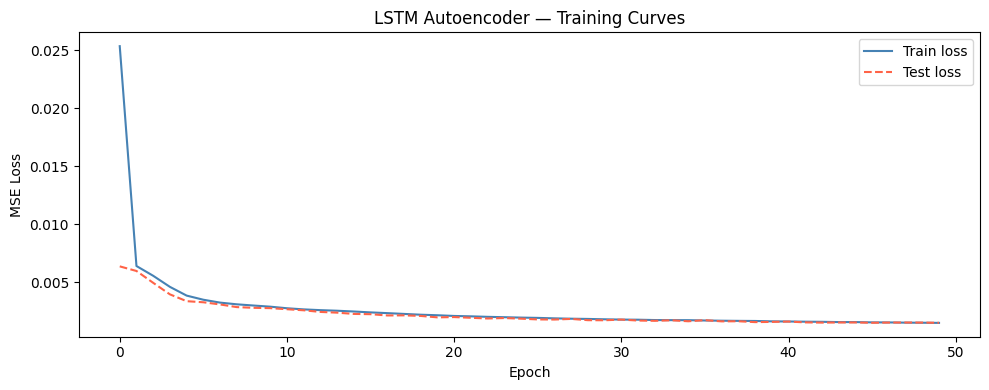

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(train_losses, label='Train loss', color='steelblue')
ax.plot(test_losses, label='Test loss', color='tomato', linestyle='--')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('LSTM Autoencoder — Training Curves')
ax.legend()

plt.tight_layout()
plt.savefig('../outputs/plots/06_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()


In [8]:
import os
os.makedirs('../models', exist_ok=True)

torch.save(model.state_dict(), '../models/lstm_autoencoder.pt')
print("Model saved")

Model saved


In [9]:
model.eval()
reconstruction_errors = []

with torch.no_grad():
    for X_batch, _ in test_loader:
        output = model(X_batch)
        # MSE per sample (mean across timesteps and features)
        errors = torch.mean((output - X_batch) ** 2, dim=(1, 2))
        reconstruction_errors.extend(errors.cpu().numpy())

reconstruction_errors = np.array(reconstruction_errors)

# Define anomaly threshold as 95th percentile of reconstruction error
threshold = np.percentile(reconstruction_errors, 95)

print(f"Mean reconstruction error: {reconstruction_errors.mean():.6f}")
print(f"Max reconstruction error:  {reconstruction_errors.max():.6f}")
print(f"Anomaly threshold (95th):  {threshold:.6f}")
print(f"Anomalies detected: {(reconstruction_errors > threshold).sum()} / {len(reconstruction_errors)}")

Mean reconstruction error: 0.001499
Max reconstruction error:  0.038255
Anomaly threshold (95th):  0.004625
Anomalies detected: 467 / 9333


In [13]:
df_clean = pd.read_csv(
    '../data/processed/turbine1_clean.csv',
    index_col='timestamp',
    parse_dates=True
)
print(f"Loaded: {df_clean.shape}")

Loaded: (46694, 9)


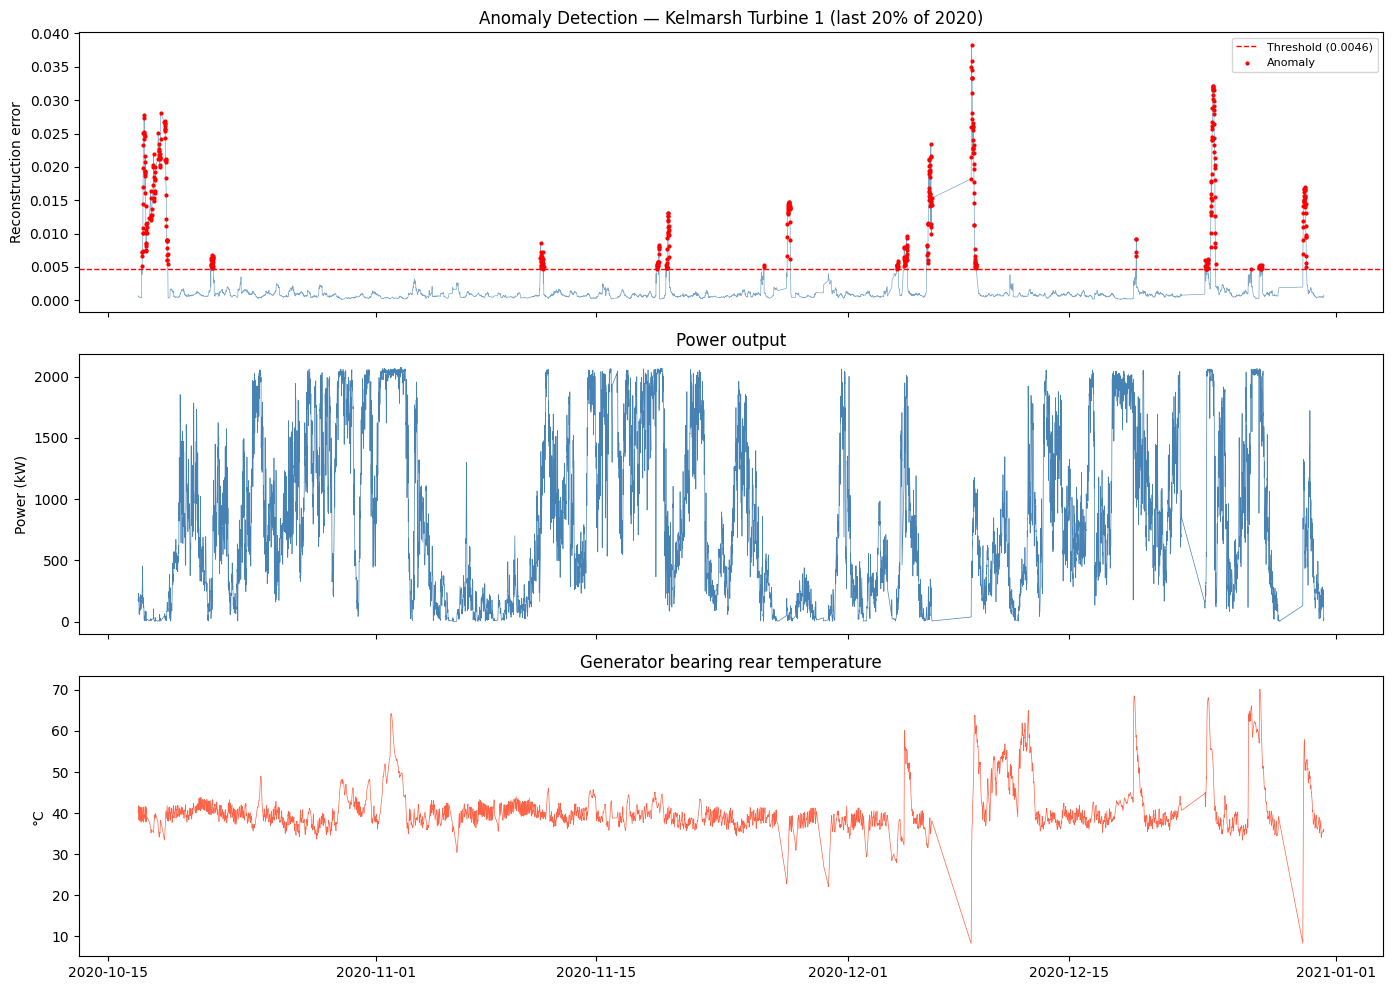

In [14]:
# Align reconstruction errors with timestamps
test_timestamps = df_clean.index[len(X_train) + 30:][:len(reconstruction_errors)]

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Reconstruction error over time
axes[0].plot(test_timestamps, reconstruction_errors, 
             color='steelblue', linewidth=0.5, alpha=0.7)
axes[0].axhline(threshold, color='red', linestyle='--', linewidth=1, label=f'Threshold ({threshold:.4f})')
axes[0].scatter(test_timestamps[reconstruction_errors > threshold],
                reconstruction_errors[reconstruction_errors > threshold],
                color='red', s=4, zorder=5, label='Anomaly')
axes[0].set_ylabel('Reconstruction error')
axes[0].set_title('Anomaly Detection — Kelmarsh Turbine 1 (last 20% of 2020)')
axes[0].legend(fontsize=8)

# Power over same period
axes[1].plot(test_timestamps, 
             df_clean['power'].iloc[len(X_train) + 30:][:len(reconstruction_errors)].values,
             color='steelblue', linewidth=0.5)
axes[1].set_ylabel('Power (kW)')
axes[1].set_title('Power output')

# Bearing rear temp over same period
axes[2].plot(test_timestamps,
             df_clean['gen_bearing_rear_temp'].iloc[len(X_train) + 30:][:len(reconstruction_errors)].values,
             color='tomato', linewidth=0.5)
axes[2].set_ylabel('°C')
axes[2].set_title('Generator bearing rear temperature')

plt.tight_layout()
plt.savefig('../outputs/plots/07_anomaly_detection.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
torch.save({
    'model_state_dict': model.state_dict(),
    'train_losses': train_losses,
    'test_losses': test_losses,
    'threshold': threshold,
}, '../models/lstm_autoencoder_full.pt')

print("Full checkpoint saved")

Full checkpoint saved
